In [34]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from cimCommand import CMD,CmdData,Packet
from cimCommand.singleCmdInfo import *

from util import plot_v_cond,plot_cond

In [35]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 51737


### 1. 处理图片

(256, 256)


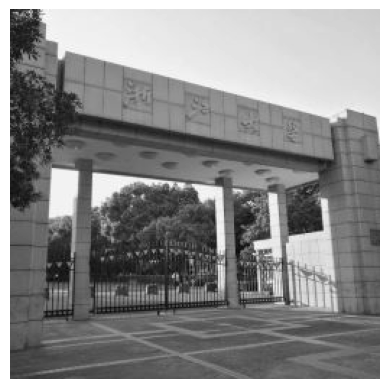

In [36]:
image_path = "./images/yuquan.jpg"
image = Image.open(image_path)

gray_image = image.convert("L")
width, height = gray_image.size
left = (width - 256) / 2
top = (height - 256) / 2
right = (width + 256) / 2
bottom = (height + 256) / 2

if width < 256 or height < 256:
    resized_image = gray_image.resize((256, 256))
else:
    cropped_image = gray_image.crop((left, top, right, bottom))
    resized_image = cropped_image.resize((256, 256))

resized_image = np.array(resized_image)
print(resized_image.shape)
plt.imshow(resized_image, cmap='gray')
plt.axis('off')
plt.show()

### 2.拟合tg和cond的线性映射

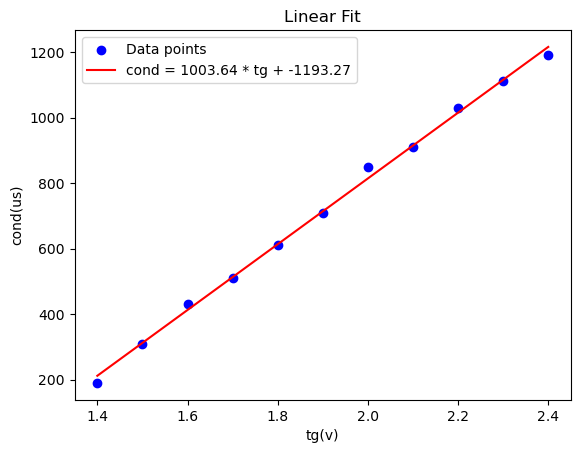

In [37]:
# 3v,set脉宽1us,reset脉宽1us
tg_map = [1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4]
cond_map = [190,310,430,510,610,710,850,910,1030,1110,1190]
# 3v,set脉宽1us,reset脉宽10us
# tg_map = [1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4]
# cond_map = [190,310,430,510,610,710,850,910,1030,1110,1190]

# 
# tg_map = [1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3]
# cond_map = [550,670,790,890,1010,1090,1170,1250]


tg_map = np.array(tg_map)
cond_map = np.array(cond_map)

coefficients = np.polyfit(tg_map, cond_map, 1)  # 返回斜率和截距
slope = coefficients[0]
intercept = coefficients[1]

y_fit = slope * tg_map + intercept

plt.scatter(tg_map, cond_map, color='blue', label='Data points')  # 原始数据点
plt.plot(tg_map, y_fit, color='red', label=f'cond = {slope:.2f} * tg + {intercept:.2f}')  # 拟合直线
plt.xlabel('tg(v)')
plt.ylabel('cond(us)')
plt.legend()
plt.title('Linear Fit')
plt.show()

### 3.直接写对应值

18.962566844921067 998.9839572192527
1.2078431372549019 2.1843137254901963
147.45989304812966 197.45989304812966


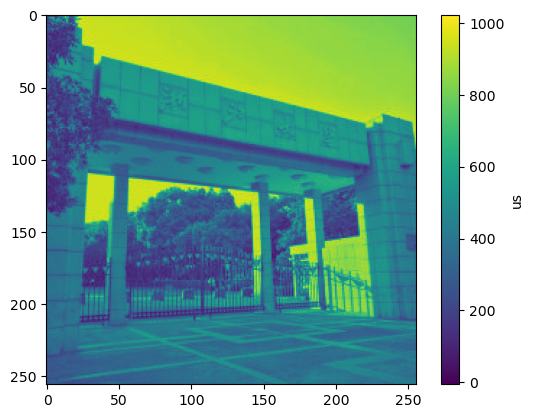

上下界


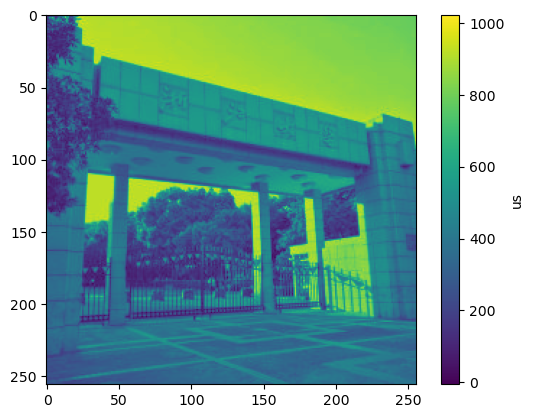

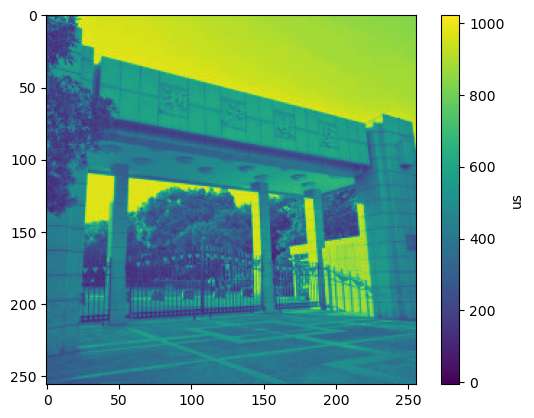

In [38]:
cond_min = slope * 1.2 + intercept
cond_max = slope * 2.2 + intercept

cond_target = cond_min + resized_image / 255 * (cond_max - cond_min)
cond_upper = cond_target + 25
cond_lower = cond_target - 25

img_tg = (cond_target - intercept)/slope
print(np.min(cond_target),np.max(cond_target),)
print(np.min(img_tg),np.max(img_tg),)

print(cond_lower[0,0],cond_upper[0,0])

plot_cond(cond_target,np.min(cond_lower),np.max(cond_upper))
print("上下界")
plot_cond(cond_lower,np.min(cond_lower),np.max(cond_upper))
plot_cond(cond_upper,np.min(cond_lower),np.max(cond_upper))

In [39]:
reversed_points = np.load("./result/reverse_points_all.npy")|np.load("./result/reverse_points4.npy")
np.save("./result/reverse_points_all.npy",reversed_points)

In [ ]:
def write_verify(write_time,img_cond_lower,img_cond_upper,tg_v,set_pulse_width,reset_pulse_width,root_path):
    vmin = np.min(img_cond_lower)
    vmax = np.max(img_cond_upper)
    need_read = np.ones((256,256),dtype=bool)
    voltage_base = np.zeros((256,256))
    voltage = np.zeros((256,256))
    cond_sub_base = None
    for i in range(write_time):
        print(f"第{i}次写验证")
        voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
        np.save(root_path+f"after_write_verify_time={int(i)}.npy", cond_sub_base)

        condition_reset = (cond_sub_base > img_cond_upper) & need_read
        condition_set = (cond_sub_base < img_cond_lower) & need_read
        need_read = condition_reset | condition_set
        
        path = root_path+f"{i}.png"
        plot_cond(cond_sub_base,vmin,vmax,title=f"{i},need_reset={int(np.sum(condition_reset))},need_set={int(np.sum(condition_set))}",path = path)


        reset_revese = reversed_points&condition_reset
        set_revese = reversed_points&condition_set

        condition_reset = condition_reset&(~reset_revese)
        condition_set = condition_set&(~set_revese)


        if i>0:
            if i<5:
                tg_v[condition_reset] -= 0.1
                tg_v[condition_set] += 0.1
            elif i<10:
                tg_v[condition_reset] -= 0.04
                tg_v[condition_set] += 0.04
            else:
                tg_v[condition_reset] -= 0.02
                tg_v[condition_set] += 0.02
        # reset的点
        chip.write_point2(crossbar=condition_reset,write_voltage=2,tg=5,pulse_width=reset_pulse_width,set_device=False)
        chip.write_point2(crossbar=condition_reset,write_voltage=3,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

        # set的点
        chip.write_point2(crossbar=condition_set,write_voltage=3+i*0.05,tg=tg_v,pulse_width=set_pulse_width,set_device=True)

        # 反的点，通过set来实现reset，再通过reset进行set
        chip.write_point2(crossbar=reset_revese,write_voltage=3,tg = 5,pulse_width=set_pulse_width,set_device=True)
        chip.write_point2(crossbar=reset_revese,write_voltage=2+i*0.05,tg=5,pulse_width=reset_pulse_width,set_device=False)

        # 通过reset进行set
        chip.write_point2(crossbar=set_revese,write_voltage=2+i*0.05,tg=5,pulse_width=reset_pulse_width,set_device=False)

        
    voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
    voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
    cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
    np.save(root_path+f"after_write_verify_time={write_time}.npy", cond_sub_base)
    np.save(root_path+f"tg_v.npy", tg_v)


    condition_reset = (cond_sub_base > img_cond_upper) & need_read
    condition_set = (cond_sub_base < img_cond_lower) & need_read
    need_read = condition_reset | condition_set
    path = root_path+f"{i}.png"
    plot_cond(cond_sub_base,vmin,vmax,title=f"{i},need_reset={int(np.sum(condition_reset))},need_set={int(np.sum(condition_set))}",path = path)
    return cond_sub_base

第0次写验证
需要读65536个点
需要读65536个点


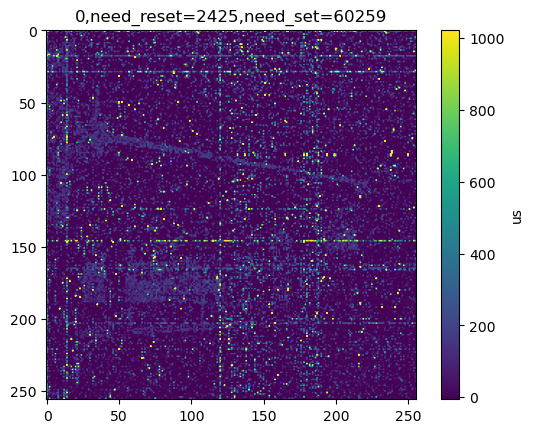

需要写304个点
需要写304个点
需要写56656个点
需要写2121个点
需要写2121个点
需要写3603个点
第1次写验证
需要读62684个点
需要读62684个点


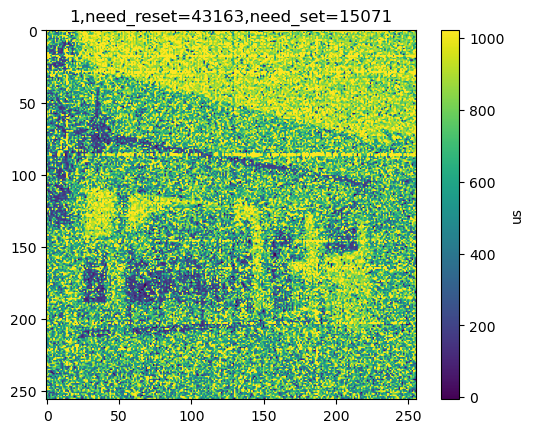

需要写38011个点
需要写38011个点
需要写14584个点
需要写5152个点
需要写5152个点
需要写487个点
第2次写验证
需要读58234个点
需要读58234个点


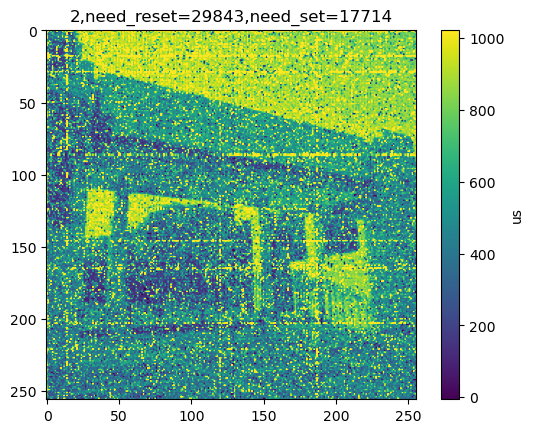

需要写24695个点
需要写24695个点
需要写17284个点
需要写5148个点
需要写5148个点
需要写430个点
第3次写验证
需要读47557个点
需要读47557个点


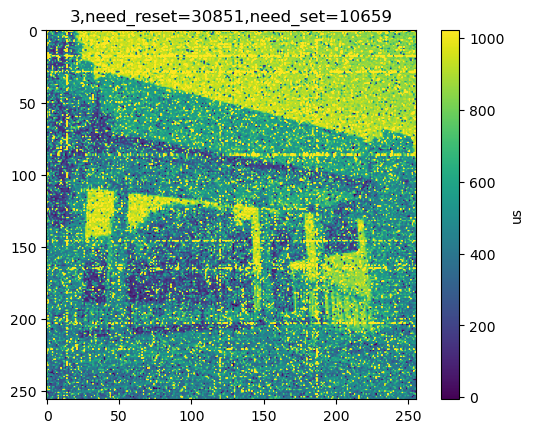

需要写25706个点
需要写25706个点
需要写10252个点
需要写5145个点
需要写5145个点
需要写407个点
第4次写验证
需要读41510个点
需要读41510个点


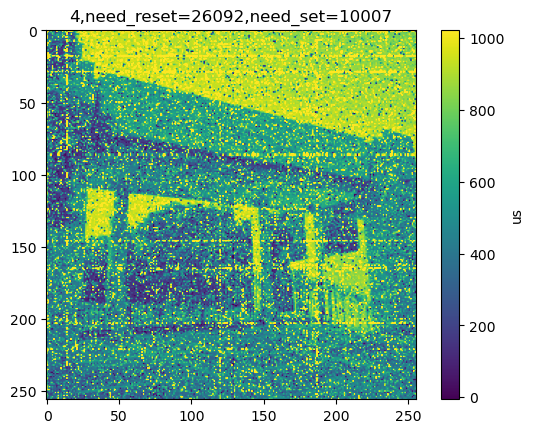

需要写20951个点
需要写20951个点
需要写9627个点
需要写5141个点
需要写5141个点
需要写380个点
第5次写验证
需要读36099个点
需要读36099个点


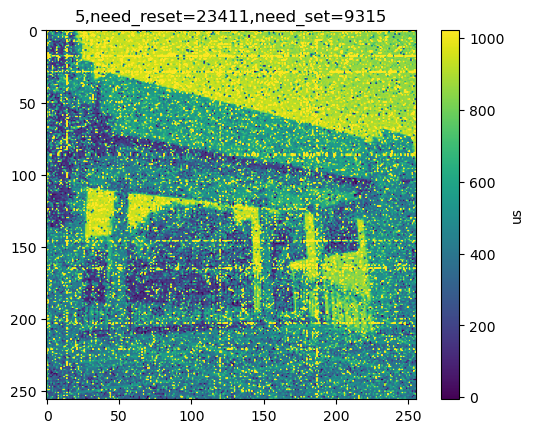

需要写18294个点
需要写18294个点
需要写8944个点
需要写5117个点
需要写5117个点
需要写371个点
第6次写验证
需要读32726个点
需要读32726个点


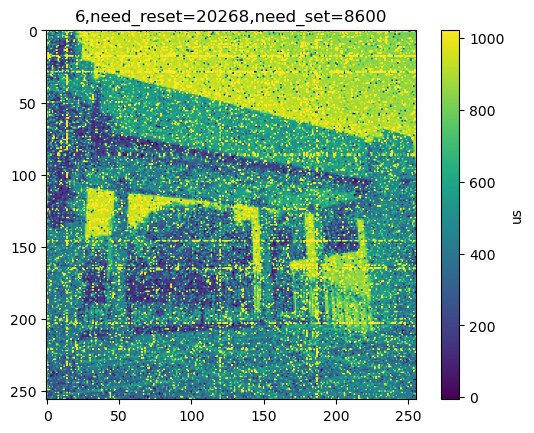

需要写15164个点
需要写15164个点
需要写8248个点
需要写5104个点
需要写5104个点
需要写352个点
第7次写验证
需要读28868个点
需要读28868个点


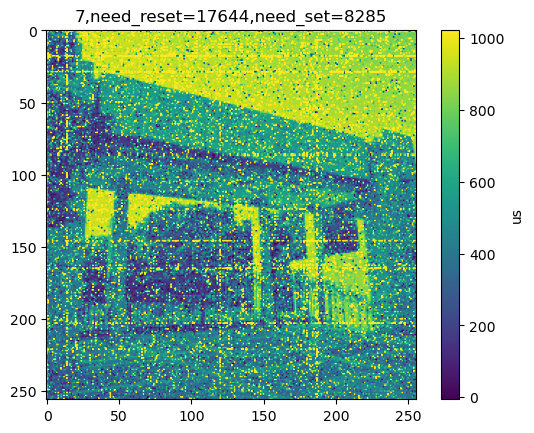

需要写12538个点
需要写12538个点
需要写7952个点
需要写5106个点
需要写5106个点
需要写333个点
第8次写验证
需要读25929个点
需要读25929个点


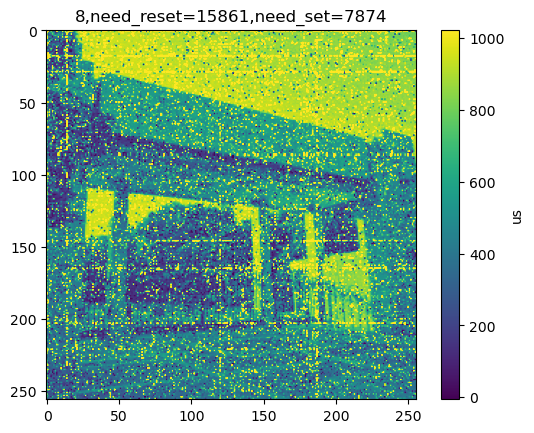

需要写10776个点
需要写10776个点
需要写7538个点
需要写5085个点
需要写5085个点
需要写336个点
第9次写验证
需要读23735个点
需要读23735个点


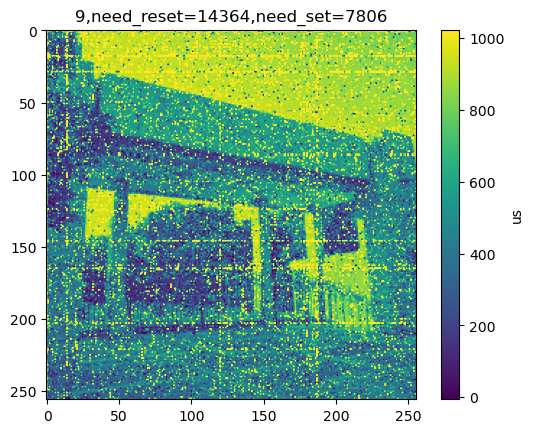

需要写9271个点
需要写9271个点
需要写7496个点
需要写5093个点
需要写5093个点
需要写310个点
第10次写验证
需要读22170个点
需要读22170个点


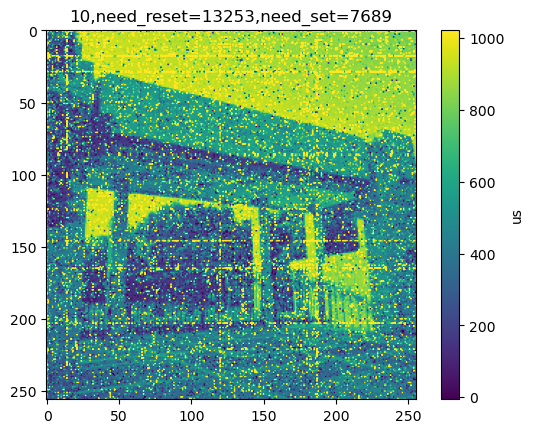

需要写8186个点
需要写8186个点
需要写7373个点
需要写5067个点
需要写5067个点
需要写316个点
第11次写验证
需要读20942个点
需要读20942个点


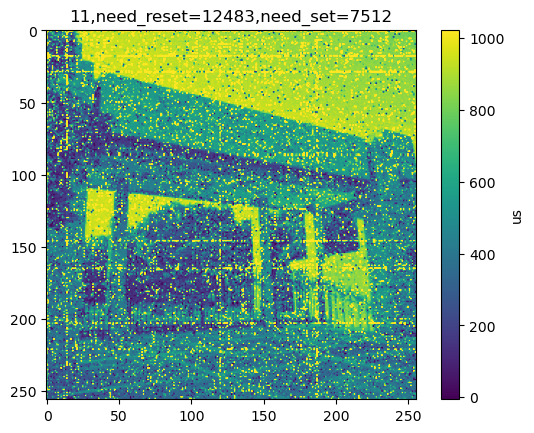

需要写7414个点
需要写7414个点
需要写7208个点
需要写5069个点
需要写5069个点
需要写304个点
第12次写验证
需要读19995个点
需要读19995个点


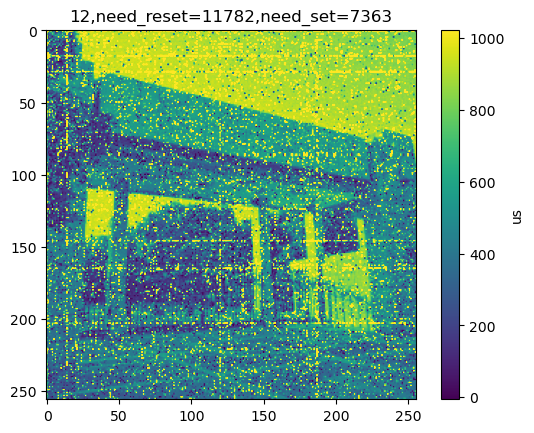

需要写6718个点
需要写6718个点
需要写7073个点
需要写5064个点
需要写5064个点
需要写290个点
第13次写验证
需要读19145个点


In [ ]:
img_tg = (cond_target - intercept)/slope
cond_sub_base = write_verify(write_time=41,img_cond_lower=cond_lower,img_cond_upper=cond_upper,
                             tg_v=img_tg,set_pulse_width=1e-6,reset_pulse_width=1e-6,root_path="./result/write_verify_12_22_6/")

In [25]:
np.save("reset_point.npy",(cond_sub_base-cond_target)>300)

In [ ]:
need_read = np.ones((256,256))
voltage_base = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base1 = chip.voltage_to_cond(voltage-voltage_base)

In [ ]:
cond_sub_base1 = np.load("result/error/cond_sub_base1.npy")
upper_bound = 500
lower_bound = -upper_bound
interval = 1
bin_edges = np.linspace(lower_bound, upper_bound, int((upper_bound-lower_bound)/interval)+1)
data = (cond_sub_base1-cond_target).flatten()
data[data<lower_bound]=lower_bound
data[data>upper_bound]=upper_bound
counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='black')
np.save(f"result/error/cond_sub_base1.npy", cond_sub_base1)
max_count = np.max(counts)
max_index = np.argmax(counts)
print(max_index,max_count)
# 添加标题和标签
plt.title(f"real_cond - target_cond")
plt.xlabel("cond(uS)")
plt.ylabel("Frequency")

plt.savefig(f"result/error/interval{interval}_{int(max_index)*interval}us_{int(max_index+1)*interval}us.png")  # 保存为 PNG 格式
plt.show()

### 4. 划分8个态写对应值

In [ ]:
state_num = 8
img = np.floor(resized_image/(256/8))
print(np.max(img))
cond_min = slope * 1.6 + intercept
cond_max = slope * 2.3 + intercept

interval = (cond_max-cond_min)/(state_num-1)
cond_target = img*interval+cond_min
img_cond_lower = cond_target - interval/2
img_cond_upper = cond_target + interval/2


img_tg = (cond_target - intercept)/slope
print(np.min(cond_target),np.max(cond_target),)
print(np.min(img_tg),np.max(img_tg),)
print(cond_lower[0,0],cond_upper[0,0])

plot_cond(cond_lower,np.min(cond_lower),np.max(cond_upper))
plot_cond(cond_upper,np.min(cond_lower),np.max(cond_upper))